In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\train.csv")

In [4]:
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(df.isnull())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

In [ ]:
# here we are using 5 columns only from the dataset
df = df[['Survived','Pclass','Sex','Age','Fare']]

In [ ]:
# here in dataset original values are - male and female and ML model cannot undertstand the text so we convert it into numerical
# here map - replaces values using dictionary
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [ ]:
# in dataset some values are null so we replace that missing values with mean age of dataset
# and here inplace - true = modifies the original dataframe directly
df['Age'].fillna(df['Age'].mean(),inplace=True) 

C:\Users\Saniya\AppData\Local\Temp\ipykernel_6700\2114215515.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
# here values - convert pandas df into numpy array
x = df[['Pclass','Sex','Age','Fare']].values
y = df['Survived'].values

In [ ]:
# features in dataset can have different ranges so we dont want one feature to dominate so we transform each feature 
# this makes gradient descent stable
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(x)

In [16]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(
    X , y , test_size =0.2 , random_state = 42
)

In [ ]:
#  n - number of features
#  w - weight
#  b - bias
# here why starting the values of w and b from zeros - 
# beacause logistic regression is convex and zero is fine
m , n =  X.shape

w = np.zeros(n)
b = 0

In [ ]:
# convert the values in probability between 0 to 1
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [ ]:
def compute_cost(X_train,y_train,w,b):
    m = len(y_train)

    # compute linear score
    z = np.dot(X_train,w)+b
    # convert them into probability
    y_hat = sigmoid(z)

    # compute log loss - how wrong probabilities are 
    cost = -np.mean(y_train*np.log(y_hat) + (1-y_train)*np.log(1-y_hat))
    return cost

In [25]:
learning_rate = 0.1

epochs = 1000

for i in range(epochs):
    z = np.dot(X_train,w)+b

    y_hat = sigmoid(z)

    # compute gradient - how much should weight change
    # here (y_hat-y_train) - is error 
    dw = np.dot(X_train.T,(y_hat-y_train))/m
    db = np.sum(y_hat-y_train)/m

    w = w - learning_rate*dw
    b = b - learning_rate*db

    if i % 100 == 0:
        print("Cost of iteration" ,i,":",compute_cost(X_train,y_train,w,b))



Cost of iteration 0 : 0.4600273971145212
Cost of iteration 100 : 0.46002670909453625
Cost of iteration 200 : 0.46002645090391703
Cost of iteration 300 : 0.4600263539772239
Cost of iteration 400 : 0.4600263175817627
Cost of iteration 500 : 0.4600263039135063
Cost of iteration 600 : 0.4600262987799645
Cost of iteration 700 : 0.46002629685179824
Cost of iteration 800 : 0.4600262961275521
Cost of iteration 900 : 0.4600262958555097


In [21]:
def predict(X,w,b):
    z = np.dot(X,w)+b
    y_hat = sigmoid(z)

    return (y_hat >= 0.5).astype(int)

In [22]:
y_pred = predict(X_test,w,b)

In [23]:
accuracy = np.mean(y_pred == y_test)
print("test accuracy: ",accuracy)

test accuracy:  0.8044692737430168


In [24]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[90 15]
 [20 54]]


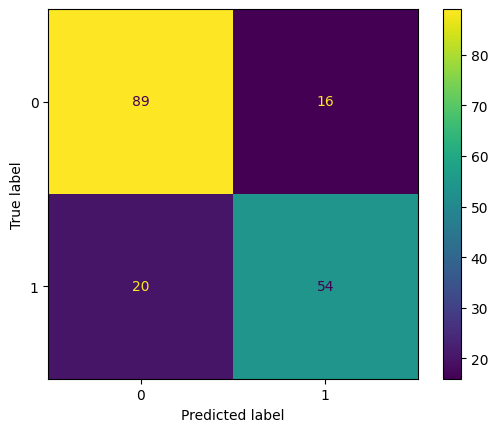

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

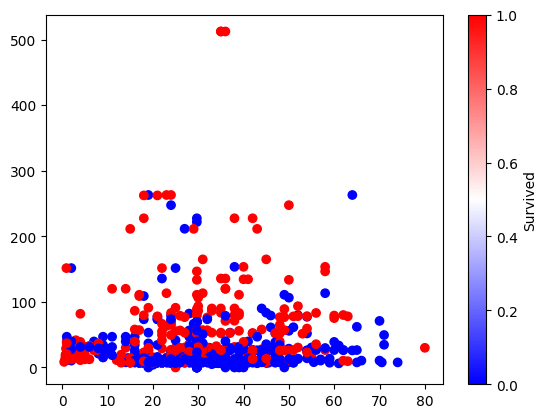

In [49]:
plt.scatter(df['Age'],df['Fare'],c=df['Survived'],cmap = 'bwr')
plt.colorbar(label = "Survived")

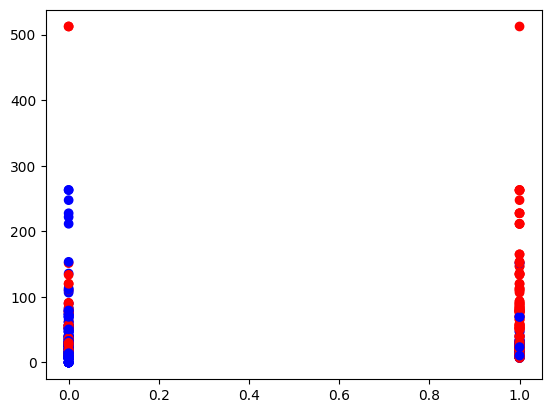

In [50]:
plt.scatter(df['Sex'],df['Fare'],c=df['Survived'],cmap = 'bwr')
